<a href="https://colab.research.google.com/github/talmolab/sleap/blob/main/docs/notebooks/Data_structures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data structures

In this notebook, we will explore some of the major data structures used in SLEAP, using [`sleap-io`](https://io.sleap.ai/) and how they can be manipulated when generating predictions from trained models. 

Note: `sleap-io` is a core dependency of SLEAP. If you have SLEAP installed, you already have `sleap-io` available—no need for a separate installation! However, [`sleap-nn`](https://nn.sleap.ai/) is an optional dependency which handles training and inference. [`sleap-nn`](https://nn.sleap.ai/) is not installed by default. Ensure [`sleap-nn`](https://nn.sleap.ai/) is installed!

A quick overview of the data structures before we start:

- `PointsArray`/`PredictedPointsArray` → Contains array of `x, y` coordinates and other metadata, like visibility/ complete flag, (and `score` for predictions) of a landmark.
- `Instance`/`PredictedInstance` → Contains `PointsArray`/`PredictedPointsArray`. This represent a single individual within a frame and may also contain an associated `Track`.
- `Skeleton` → Defines the nodes and edges that define the set of unique landmark types that each point represents, e.g., "head", "tail", etc. This *does not contain positions* -- those are stored in individual `PointsArray`s.
- `LabeledFrame` → Contains a set of `Instance`/`PredictedInstance`s for a single frame.
- `Labels` → Contains a set of `LabeledFrame`s and the associated metadata for the videos and other information related to the project or predictions.

## 1. Setup dependencies and data

We'll start by installing [`sleap-io`](https://io.sleap.ai/#installation) and downloading some data and models to play around with.

If you get a dependency error in subsequent cells, just click **Runtime** → **Restart runtime** to reload the packages.

In [ ]:
# This should take care of all the IO dependencies on colab:
!pip install -qqq "sleap-io"

# This should take care of all the torch dependencies on colab:
!pip install -qqq "sleap-nn[torch-cpu]" 

# if you have GPU (in colab, enable GPU runtime)
# !pip install -qqq "sleap-nn[torch-cuda-128]"


In [2]:
# Test video:
!wget https://storage.googleapis.com/sleap-data/reference/flies13/190719_090330_wt_18159206_rig1.2%4015000-17560.mp4

# Test video labels (from predictions/not necessary for inference benchmarking):
!wget https://storage.googleapis.com/sleap-data/reference/flies13/190719_090330_wt_18159206_rig1.2%4015000-17560.slp

# Bottom-up model:
# !wget https://storage.googleapis.com/sleap-data/reference/flies13/bu.210506_230852.multi_instance.n%3D1800.zip

# Top-down model (two-stage):
!wget https://storage.googleapis.com/sleap-data/reference/flies13/centroid.fast.210504_182918.centroid.n%3D1800.zip
!wget https://storage.googleapis.com/sleap-data/reference/flies13/td_fast.210505_012601.centered_instance.n%3D1800.zip

--2025-09-22 11:16:31--  https://storage.googleapis.com/sleap-data/reference/flies13/190719_090330_wt_18159206_rig1.2%4015000-17560.mp4
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.72.251, 142.251.40.59, 142.250.176.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.72.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85343812 (81M) [video/mp4]
Saving to: ‘190719_090330_wt_18159206_rig1.2@15000-17560.mp4’

190719_090330_wt_18 100%[===================>]  81.39M  26.3MB/s    in 3.1s    

2025-09-22 11:16:34 (26.3 MB/s) - ‘190719_090330_wt_18159206_rig1.2@15000-17560.mp4’ saved [85343812/85343812]

--2025-09-22 11:16:35--  https://storage.googleapis.com/sleap-data/reference/flies13/190719_090330_wt_18159206_rig1.2%4015000-17560.slp
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.72.251, 142.251.40.59, 142.250.176.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.

In [3]:
# In Google Colab, unzip is installed by default, so we can just run:
import os

# Unzip each file into a directory named after the zip file (without .zip)
for zip_file in [
    "centroid.fast.210504_182918.centroid.n=1800.zip",
    "td_fast.210505_012601.centered_instance.n=1800.zip"
]:
    dir_name = os.path.splitext(zip_file)[0]
    os.makedirs(dir_name, exist_ok=True)
    # The -d flag tells unzip to extract into the given directory
    !unzip -o "{zip_file}" -d "{dir_name}"


Archive:  centroid.fast.210504_182918.centroid.n=1800.zip
  inflating: centroid.fast.210504_182918.centroid.n=1800/best_model.h5  
  inflating: centroid.fast.210504_182918.centroid.n=1800/initial_config.json  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_gt.test.slp  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_gt.train.slp  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_gt.val.slp  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_pr.test.slp  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_pr.train.slp  
  inflating: centroid.fast.210504_182918.centroid.n=1800/labels_pr.val.slp  
 extracting: centroid.fast.210504_182918.centroid.n=1800/metrics.test.npz  
  inflating: centroid.fast.210504_182918.centroid.n=1800/metrics.train.npz  
  inflating: centroid.fast.210504_182918.centroid.n=1800/metrics.val.npz  
  inflating: centroid.fast.210504_182918.centroid.n=1800/model_info.json  
  inflating: centro

In [4]:
!ls -lah

total 278704
drwxr-xr-x@ 19 divyasesh  staff   608B Sep 22 11:16 .
drwxr-xr-x@ 14 divyasesh  staff   448B Sep 19 20:29 ..
-rw-r--r--@  1 divyasesh  staff    81M May 20  2021 190719_090330_wt_18159206_rig1.2@15000-17560.mp4
-rw-r--r--@  1 divyasesh  staff   1.5M May 20  2021 190719_090330_wt_18159206_rig1.2@15000-17560.slp
-rw-r--r--@  1 divyasesh  staff   713K Sep 22 10:30 Analysis_examples.ipynb
-rw-r--r--@  1 divyasesh  staff   461K Sep 22 11:16 Data_structures.ipynb
-rw-r--r--@  1 divyasesh  staff   179K Sep 19 19:36 Interactive_and_realtime_inference.ipynb
-rw-r--r--@  1 divyasesh  staff    45K Sep 19 19:36 Interactive_and_resumable_training.ipynb
-rw-r--r--@  1 divyasesh  staff   157K Sep 19 19:36 Model_evaluation.ipynb
-rw-r--r--@  1 divyasesh  staff   132K Sep 19 19:36 Post_inference_tracking.ipynb
-rw-r--r--@  1 divyasesh  staff   471K Sep 19 19:36 SLEAP_Tutorial_at_Cosyne_2024_Using_exported_data.ipynb
-rw-r--r--@  1 divyasesh  staff    93K Sep 19 19:36 Training_and_inference_

In [5]:
import sleap_io as sio

sio.__version__

'0.5.3'

In [6]:
import sleap_nn as snn

snn.__version__

'0.0.1'

## 2. Data structures and inference

sleap-io can read videos in a variety of different formats through the `sio.load_video` high level API. Once loaded, the `sio.Video` object allows you to access individual frames as if the it were a standard numpy array.

**Note:** The actual frames are not loaded until you access them so we don't blow up our memory when using long videos.

In [7]:
video_path = "190719_090330_wt_18159206_rig1.2@15000-17560.mp4"

# Videos can be represented agnostic to the backend format
video = sio.load_video(video_path)

# sleap.Video objects have a numpy-like interface:
print(video.shape)

# And we can load images in the video using array indexing:
imgs = video[:4]
print(imgs.shape, imgs.dtype)

(2560, 1024, 1024, 1)
(4, 1024, 1024, 1) uint8


The high level interface for running inference (`sleap_nn.predict.run_inference()`) takes model folders as input and returns a `sio.Labels` object with the predicted instances. These are outputs from our training procedure and need to contain a `"best.ckpt"` (or `best_model.h5` for SLEAP <= 1.4.1.)  and `"training_config.yaml"` (or `training_config.json` for SLEAP <= 1.4.1).
 
`best.ckpt` is a checkpoint file containing the Torch model weights that was saved during
training. It includes the model's parameters, so they're standalone and don't need SLEAP/ SLEAP-NN -- 
BUT they do not contain the inference methods.

`training_config.yaml` is a serialized `sleap_nn.config.TrainingJobConfig` that contains metadata
like what channels of the model correspond to what landmarks and etc.

Top-down models have two stages: centroid and centered instance confidence maps, which we train and save out separately, so loading them together links them up into a single inference model.

In [8]:
from sleap_nn.predict import run_inference

# Top-down
labels = run_inference(data_path=video_path, model_paths=[
    "centroid.fast.210504_182918.centroid.n=1800",
    "td_fast.210505_012601.centered_instance.n=1800"
    ])

# Predicted labels
labels

# Bottom-up
# labels = run_inference(data_path=video_path, model_paths=[
#     "bu.210506_230852.multi_instance.n=1800.zip"
#     ])

2025-09-22 11:16:42 | INFO | sleap_nn.predict:run_inference:291 | Started inference at: 2025-09-22 11:16:42.955460
2025-09-22 11:16:42 | INFO | sleap_nn.predict:run_inference:302 | Integral refinement is not supported with MPS device. Using CPU.
2025-09-22 11:16:42 | INFO | sleap_nn.predict:run_inference:307 | Using device: cpu
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:269 | Successfully mapped 34/34 legacy weights to PyTorch parameters
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:360 | Successfully loaded 34/34 weights from legacy model
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:371 | Verifying weight assignments...
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:4

Output()

2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:269 | Successfully mapped 34/34 legacy weights to PyTorch parameters
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:360 | Successfully loaded 34/34 weights from legacy model
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:371 | Verifying weight assignments...
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:426 | ✓ All weight assignments verified successfully
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-22 11:16:43 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:269 | Su

2025-09-22 11:22:14 | INFO | sleap_nn.predict:run_inference:421 | Finished inference at: 2025-09-22 11:22:14.085145
2025-09-22 11:22:14 | INFO | sleap_nn.predict:run_inference:422 | Total runtime: 331.1298098564148 secs
2025-09-22 11:22:14 | INFO | sleap_nn.predict:run_inference:431 | Predictions output path: 190719_090330_wt_18159206_rig1.2@15000-17560.predictions.slp
2025-09-22 11:22:14 | INFO | sleap_nn.predict:run_inference:432 | Saved file at: 2025-09-22 11:22:14.194343


Labels(labeled_frames=2560, videos=1, skeletons=1, tracks=0, suggestions=0, sessions=0)

Labels contain not just the predicted data, but all the other associated data structures and metadata:

In [9]:
labels.videos

[Video(filename="190719_090330_wt_18159206_rig1.2@15000-17560.mp4", shape=(2560, 1024, 1024, 1), backend=MediaVideo)]

In [10]:
labels.skeletons

[Skeleton(nodes=["head", "thorax", "abdomen", "wingL", "wingR", "forelegL4", "forelegR4", "midlegL4", "midlegR4", "hindlegL4", "hindlegR4", "eyeL", "eyeR"], edges=[(0, 11), (0, 12), (1, 0), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10)])]

Individual labeled frames are accessible through a list-like interface:

In [11]:
labeled_frame = labels[0]  # shortcut for labels.labeled_frames[0]
labeled_frame

LabeledFrame(video=Video(filename="190719_090330_wt_18159206_rig1.2@15000-17560.mp4", shape=(2560, 1024, 1024, 1), backend=MediaVideo), frame_idx=0, instances=[PredictedInstance(points=[[234.6404266357422, 430.84320068359375], [271.8457336425781, 436.1230773925781], [308.34124755859375, 438.6607971191406], [321.9830627441406, 440.3363952636719], [322.0407409667969, 437.0755615234375], [246.48248291015625, 450.92755126953125], [242.76162719726562, 413.98126220703125], [286.1595764160156, 460.1742858886719], [272.72576904296875, 407.01220703125], [nan, nan], [318.0406494140625, 430.85784912109375], [242.54898071289062, 442.32696533203125], [245.7898712158203, 422.02001953125]], track=None, score=0.94, tracking_score=None), PredictedInstance(points=[[319.83282470703125, 436.218017578125], [354.3247375488281, 435.20550537109375], [369.22540283203125, 433.84979248046875], [394.0439453125, 481.4942321777344], [399.39190673828125, 430.14251708984375], [307.92706298828125, 446.9759826660156], 

Convenient methods allow for easy inspection:

In [12]:
import seaborn as sns
from typing import Union, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

def imgfig(
    size: Union[float, Tuple] = 6, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Create a tight figure for image plotting.

    Args:
        size: Scalar or 2-tuple specifying the (width, height) of the figure in inches.
            If scalar, will assume equal width and height.
        dpi: Dots per inch, controlling the resolution of the image.
        scale: Factor to scale the size of the figure by. This is a convenience for
            increasing the size of the plot at the same DPI.

    Returns:
        A matplotlib.figure.Figure to use for plotting.
    """
    if not isinstance(size, (tuple, list)):
        size = (size, size)
    fig = plt.figure(figsize=(scale * size[0], scale * size[1]), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.autoscale(tight=True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    return fig

def plot_img(
    img: np.ndarray, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Plot an image in a tight figure."""
    if hasattr(img, "numpy"):
        img = img.numpy()

    if img.shape[0] == 1:
        # Squeeze out batch singleton dimension.
        img = img.squeeze(axis=0)

    # Check if image is grayscale (single channel).
    grayscale = img.shape[-1] == 1
    if grayscale:
        # Squeeze out singleton channel.
        img = img.squeeze(axis=-1)

    # Normalize the range of pixel values.
    img_min = img.min()
    img_max = img.max()
    if img_min < 0.0 or img_max > 1.0:
        img = (img - img_min) / (img_max - img_min)

    fig = imgfig(
        size=(float(img.shape[1]) / dpi, float(img.shape[0]) / dpi),
        dpi=dpi,
        scale=scale,
    )

    ax = fig.gca()
    ax.imshow(
        img,
        cmap="gray" if grayscale else None,
        origin="upper",
        extent=[-0.5, img.shape[1] - 0.5, img.shape[0] - 0.5, -0.5],
    )
    return fig

def plot_instance(
    instance,
    skeleton=None,
    cmap=None,
    color_by_node=False,
    lw=2,
    ms=10,
    bbox=None,
    scale=1.0,
    **kwargs,
):
    """Plot a single instance with edge coloring."""
    if cmap is None:
        cmap = sns.color_palette("tab20")

    if skeleton is None and hasattr(instance, "skeleton"):
        skeleton = instance.skeleton

    if skeleton is None:
        color_by_node = True
    else:
        if len(skeleton.edges) == 0:
            color_by_node = True

    if hasattr(instance, "numpy"):
        inst_pts = instance.numpy()
    else:
        inst_pts = instance

    h_lines = []
    if color_by_node:
        for k, (x, y) in enumerate(inst_pts):
            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(x, y, ".", ms=ms, c=cmap[k % len(cmap)], **kwargs)
            h_lines.append(h_lines_k)

    else:
        for k, (src_node, dst_node) in enumerate(skeleton.edges):
            pts = instance.numpy()
            src_pt = pts[skeleton.node_names.index(src_node.name)]
            dst_pt = pts[skeleton.node_names.index(dst_node.name)]

            x = np.array([src_pt[0], dst_pt[0]])
            y = np.array([src_pt[1], dst_pt[1]])

            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(
                x, y, ".-", ms=ms, lw=lw, c=cmap[k % len(cmap)], **kwargs
            )

            h_lines.append(h_lines_k)

    return h_lines

def plot_instances(
    instances, skeleton=None, cmap=None, color_by_track=False, tracks=None, **kwargs
):
    """Plot a list of instances with identity coloring."""

    if cmap is None:
        cmap = sns.color_palette("tab10")

    if color_by_track and tracks is None:
        # Infer tracks for ordering if not provided.
        tracks = set()
        for instance in instances:
            tracks.add(instance.track)

        # Sort by spawned frame.
        tracks = sorted(list(tracks), key=lambda track: track.name)

    h_lines = []
    for i, instance in enumerate(instances):
        if color_by_track:
            if instance.track is None:
                raise ValueError(
                    "Instances must have a set track when coloring by track."
                )

            if instance.track not in tracks:
                raise ValueError("Instance has a track not found in specified tracks.")

            color = cmap[tracks.index(instance.track) % len(cmap)]

        else:
            # Color by identity (order in list).
            color = cmap[i % len(cmap)]

        h_lines_i = plot_instance(instance, skeleton=skeleton, cmap=[color], **kwargs)
        h_lines.append(h_lines_i)

    return h_lines

def plot(lf, scale=0.5):
    plot_img(lf.image, scale=scale)
    plot_instances(lf.instances)

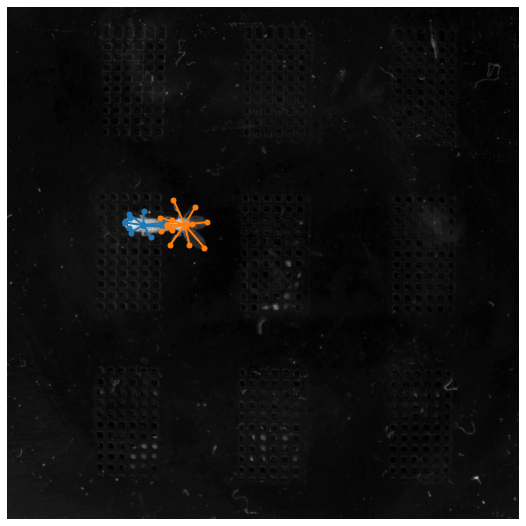

In [13]:
plot(labels[0], scale=0.5)

The labeled frame is itself a container for instances:

In [14]:
labeled_frame.instances

[PredictedInstance(points=[[234.6404266357422, 430.84320068359375], [271.8457336425781, 436.1230773925781], [308.34124755859375, 438.6607971191406], [321.9830627441406, 440.3363952636719], [322.0407409667969, 437.0755615234375], [246.48248291015625, 450.92755126953125], [242.76162719726562, 413.98126220703125], [286.1595764160156, 460.1742858886719], [272.72576904296875, 407.01220703125], [nan, nan], [318.0406494140625, 430.85784912109375], [242.54898071289062, 442.32696533203125], [245.7898712158203, 422.02001953125]], track=None, score=0.94, tracking_score=None),
 PredictedInstance(points=[[319.83282470703125, 436.218017578125], [354.3247375488281, 435.20550537109375], [369.22540283203125, 433.84979248046875], [394.0439453125, 481.4942321777344], [399.39190673828125, 430.14251708984375], [307.92706298828125, 446.9759826660156], [305.74822998046875, 421.2812194824219], [325.94049072265625, 475.3349609375], [332.0487365722656, 385.46990966796875], [364.0356750488281, 475.0806884765625]

In [15]:
instance = labeled_frame[0]  # shortcut for labeled_frame.instances[0]
instance

PredictedInstance(points=[[234.6404266357422, 430.84320068359375], [271.8457336425781, 436.1230773925781], [308.34124755859375, 438.6607971191406], [321.9830627441406, 440.3363952636719], [322.0407409667969, 437.0755615234375], [246.48248291015625, 450.92755126953125], [242.76162719726562, 413.98126220703125], [286.1595764160156, 460.1742858886719], [272.72576904296875, 407.01220703125], [nan, nan], [318.0406494140625, 430.85784912109375], [242.54898071289062, 442.32696533203125], [245.7898712158203, 422.02001953125]], track=None, score=0.94, tracking_score=None)

Finally, instances are containers for points:

In [16]:
instance.points

PredictedPointsArray([([234.64042664, 430.84320068], 0.93376952,  True, False, 'head'),
                      ([271.84573364, 436.12307739], 0.93177146,  True, False, 'thorax'),
                      ([308.34124756, 438.66079712], 0.59078413,  True, False, 'abdomen'),
                      ([321.98306274, 440.33639526], 0.41335493,  True, False, 'wingL'),
                      ([322.04074097, 437.07556152], 0.45038646,  True, False, 'wingR'),
                      ([246.48248291, 450.92755127], 0.86102617,  True, False, 'forelegL4'),
                      ([242.7616272 , 413.98126221], 0.75765818,  True, False, 'forelegR4'),
                      ([286.15957642, 460.17428589], 0.58625907,  True, False, 'midlegL4'),
                      ([272.72576904, 407.01220703], 0.75733137,  True, False, 'midlegR4'),
                      ([         nan,          nan], 0.        , False, False, 'hindlegL4'),
                      ([318.04064941, 430.85784912], 0.26891908,  True, False, 'hindlegR4'

These can be converted into concrete arrays:

In [17]:
pts = instance.numpy()
print(pts)

[[234.64042664 430.84320068]
 [271.84573364 436.12307739]
 [308.34124756 438.66079712]
 [321.98306274 440.33639526]
 [322.04074097 437.07556152]
 [246.48248291 450.92755127]
 [242.7616272  413.98126221]
 [286.15957642 460.17428589]
 [272.72576904 407.01220703]
 [         nan          nan]
 [318.04064941 430.85784912]
 [242.54898071 442.32696533]
 [245.78987122 422.02001953]]


Images can be embedded together with the predictions in the same format:

In [18]:
labels = sio.Labels(labels.labeled_frames[:4], videos=labels.videos, skeletons=labels.skeletons)  # crop to the first few labels for this example
labels.save("labels_with_images.pkg.slp", embed="all")

Embedding frames: 100%|██████████| 4/4 [00:00<00:00, 65.37it/s]


Let's delete the source data:

In [19]:
!rm "190719_090330_wt_18159206_rig1.2@15000-17560.mp4"

And check out what happens when we load in some labels with embedded images:

In [20]:
labels = sio.load_slp("labels_with_images.pkg.slp")
labels

Labels(labeled_frames=4, videos=1, skeletons=1, tracks=0, suggestions=0, sessions=0)

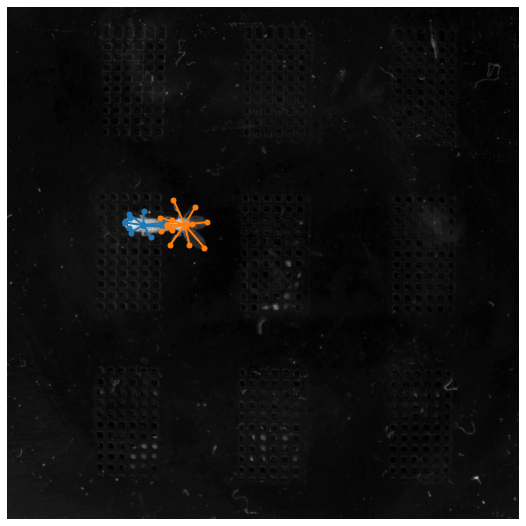

In [21]:
plot(labels[0], scale=0.5)